# Student Performance Factors Dataset
## Exploración, limpieza y preparación de datos

**Dataset:** Student Performance Factors Dataset  
**Autor:** Mosap Abdel-Ghany  
**Fuente:** Kaggle  
**Liga de acceso:** https://www.kaggle.com/datasets/mosapabdelghany/student-performance-factors-dataset  
**Fecha de consulta:** 14 de agosto de 2026  
**Última actualización reportada:** Aproximadamente octubre de 2025. Kaggle reporta actualmente "Updated 10 months ago".  

### Descripción

El conjunto de datos contiene información de 6,607 estudiantes y diferentes factores que pueden influir en su desempeño académico.

Incluye variables relacionadas con hábitos de estudio, asistencia, recursos educativos, entorno familiar, motivación, características escolares y desempeño previo.

Cada registro representa a un estudiante y sus características académicas, personales, familiares y escolares.

## Posible problema de aprendizaje automático

La variable **Exam_Score** representa el puntaje obtenido por cada estudiante en un examen y puede utilizarse como variable objetivo.

Como Exam_Score es una variable numérica, el problema puede plantearse como una tarea de **regresión**, donde el objetivo sería predecir el puntaje de examen de un estudiante utilizando los demás factores disponibles.

Un modelo de este tipo podría ayudar a identificar factores relacionados con el desempeño académico y detectar estudiantes que podrían necesitar apoyo adicional.

En esta actividad todavía no se entrenará un modelo. El objetivo es explorar, limpiar y preparar los datos para que puedan utilizarse posteriormente.

In [14]:
# libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [15]:
# upload dataset

uploaded = files.upload()

Saving StudentPerformanceFactors.csv to StudentPerformanceFactors (1).csv


In [16]:
# load dataset

df = pd.read_csv("StudentPerformanceFactors.csv")

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [17]:
# save initial state

initial_rows = df.shape[0]
initial_cols = df.shape[1]
initial_missing = int(df.isna().sum().sum())
initial_duplicates = int(df.duplicated().sum())

print("shape:")
print(df.shape)

print("\ncolumns:")
print(df.columns.tolist())

print("\ndata types:")
print(df.dtypes)

print("\nmissing values:")
print(df.isna().sum())

print("\nduplicated rows:")
print(df.duplicated().sum())

print("\nunique values per column:")
print(df.nunique(dropna=False))

shape:
(6607, 20)

columns:
['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']

data types:
Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities    object
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access               object
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Influence                object
Physical_Activity              int64
Learning_Dis

In [18]:
# sample records

display(df.head(10))

# descriptive statistics

display(df.describe())

# categorical statistics

display(df.describe(include="object"))

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
5,19,88,Medium,Medium,Yes,8,89,Medium,Yes,3,Medium,Medium,Public,Positive,3,No,Postgraduate,Near,Male,71
6,29,84,Medium,Low,Yes,7,68,Low,Yes,1,Low,Medium,Private,Neutral,2,No,High School,Moderate,Male,67
7,25,78,Low,High,Yes,6,50,Medium,Yes,1,High,High,Public,Negative,2,No,High School,Far,Male,66
8,17,94,Medium,High,No,6,80,High,Yes,0,Medium,Low,Private,Neutral,1,No,College,Near,Male,69
9,23,98,Medium,Medium,Yes,8,71,Medium,Yes,0,High,High,Public,Positive,5,No,High School,Moderate,Male,72


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Motivation_Level,Internet_Access,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender
count,6607,6607,6607,6607,6607,6607,6529,6607,6607,6607,6517,6540,6607
unique,3,3,2,3,2,3,3,2,3,2,3,3,2
top,Medium,Medium,Yes,Medium,Yes,Low,Medium,Public,Positive,No,High School,Near,Male
freq,3362,3319,3938,3351,6108,2672,3925,4598,2638,5912,3223,3884,3814


## Interpretación del estado inicial

El dataset contiene **6,607 registros y 20 variables**.

Se observan tanto variables numéricas como categóricas, por lo que será necesario aplicar distintos métodos de preparación antes de utilizar los datos en un modelo.

La mayoría de las variables presenta información completa, aunque existen valores faltantes en algunas variables categóricas.

No se observan identificadores explícitos de estudiantes, por lo que todas las variables disponibles tienen potencial utilidad analítica.

También será necesario revisar los rangos de las variables numéricas, especialmente Exam_Score, para identificar valores que puedan ser imposibles o inconsistentes.

In [19]:
# quality checks

missing_columns = df.isna().sum()
missing_columns = missing_columns[missing_columns > 0]

duplicate_count = df.duplicated().sum()

constant_columns = [
    col for col in df.columns
    if df[col].nunique(dropna=False) <= 1
]

numeric_text_columns = []

for col in df.select_dtypes(include="object").columns:
    converted = pd.to_numeric(df[col], errors="coerce")

    if converted.notna().mean() > 0.90:
        numeric_text_columns.append(col)

invalid_exam_scores = ((df["Exam_Score"] < 0) | (df["Exam_Score"] > 100)).sum()

issues = pd.DataFrame({
    "Problema detectado": [
        "Valores faltantes",
        "Registros duplicados",
        "Valor fuera del rango esperado",
        "Variables constantes",
        "Columnas numéricas almacenadas como texto",
        "Identificadores sin utilidad predictiva"
    ],

    "Variable afectada": [
        ", ".join(missing_columns.index),
        "Todas",
        "Exam_Score",
        ", ".join(constant_columns) if constant_columns else "Ninguna",
        ", ".join(numeric_text_columns) if numeric_text_columns else "Ninguna",
        "Ninguna"
    ],

    "Evidencia": [
        str(missing_columns.to_dict()),
        f"{duplicate_count} duplicados",
        f"{invalid_exam_scores} valores fuera de 0-100",
        str(constant_columns),
        str(numeric_text_columns),
        "No existe una columna ID"
    ],

    "Tratamiento propuesto": [
        "Imputar con la moda de cada variable categórica",
        "Eliminar duplicados si existen",
        "Eliminar registros con puntajes imposibles",
        "Eliminar solo si se detectan",
        "Convertir a tipo numérico",
        "No se requiere tratamiento"
    ]
})

display(issues)

,Problema detectado,Variable afectada,Evidencia,Tratamiento propuesto
0,Valores faltantes,"Teacher_Quality, Parental_Education_Level, Dis...","{'Teacher_Quality': 78, 'Parental_Education_Le...",Imputar con la moda de cada variable categórica
1,Registros duplicados,Todas,0 duplicados,Eliminar duplicados si existen
2,Valor fuera del rango esperado,Exam_Score,1 valores fuera de 0-100,Eliminar registros con puntajes imposibles
3,Variables constantes,Ninguna,[],Eliminar solo si se detectan
4,Columnas numéricas almacenadas como texto,Ninguna,[],Convertir a tipo numérico
5,Identificadores sin utilidad predictiva,Ninguna,No existe una columna ID,No se requiere tratamiento


In [20]:
# detect possible outliers using iqr

numeric_columns = df.select_dtypes(include=np.number).columns

outlier_results = []

for col in numeric_columns:

    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_results.append({
        "Variable": col,
        "Possible_Outliers": count,
        "Minimum": df[col].min(),
        "Maximum": df[col].max()
    })

outlier_table = pd.DataFrame(outlier_results)

display(outlier_table)

,Variable,Possible_Outliers,Minimum,Maximum
0,Hours_Studied,43,1,44
1,Attendance,0,60,100
2,Sleep_Hours,0,4,10
3,Previous_Scores,0,50,100
4,Tutoring_Sessions,430,0,8
5,Physical_Activity,0,0,6
6,Exam_Score,104,55,101


## Diagnóstico de calidad

La revisión muestra que los principales problemas del dataset son los valores faltantes presentes en algunas variables categóricas y la existencia de valores extremos en ciertas variables numéricas.

Un valor extremo no debe eliminarse automáticamente, ya que puede representar un caso real. Por esta razón, los valores atípicos detectados mediante el rango intercuartílico se conservarán mientras se encuentren dentro de límites razonables.

En Exam_Score se identificó al menos un valor superior a 100. Si se considera que el examen utiliza una escala de 0 a 100, este valor es imposible y debe ser tratado.

Las categorías también serán estandarizadas eliminando espacios adicionales para evitar que dos textos equivalentes sean interpretados como categorías diferentes.

In [21]:
# create clean copy

clean_df = df.copy()

# clean column names

clean_df.columns = (
    clean_df.columns
    .str.strip()
    .str.replace(r"\s+", "_", regex=True)
)

# remove duplicates

clean_df = clean_df.drop_duplicates()

# expected numeric columns

numeric_columns = [
    "Hours_Studied",
    "Attendance",
    "Sleep_Hours",
    "Previous_Scores",
    "Tutoring_Sessions",
    "Physical_Activity",
    "Exam_Score"
]

# convert numeric columns

for col in numeric_columns:
    clean_df[col] = pd.to_numeric(clean_df[col], errors="coerce")

# clean categorical values

categorical_columns = clean_df.select_dtypes(include=["object", "string"]).columns

for col in categorical_columns:
    clean_df[col] = (
        clean_df[col]
        .astype("string")
        .str.strip()
    )

# fill missing categorical values with mode

for col in categorical_columns:

    if clean_df[col].isna().any():
        clean_df[col] = clean_df[col].fillna(clean_df[col].mode()[0])

# filter impossible ranges

clean_df = clean_df[
    clean_df["Hours_Studied"].between(0, 168)
]

clean_df = clean_df[
    clean_df["Attendance"].between(0, 100)
]

clean_df = clean_df[
    clean_df["Sleep_Hours"].between(0, 24)
]

clean_df = clean_df[
    clean_df["Previous_Scores"].between(0, 100)
]

clean_df = clean_df[
    clean_df["Tutoring_Sessions"] >= 0
]

clean_df = clean_df[
    clean_df["Physical_Activity"] >= 0
]

clean_df = clean_df[
    clean_df["Exam_Score"].between(0, 100)
]

clean_df = clean_df.reset_index(drop=True)

In [22]:
# verify cleaning

print("original shape:", df.shape)
print("clean shape:", clean_df.shape)

print("\nmissing values:")
print(clean_df.isna().sum().sum())

print("\nduplicates:")
print(clean_df.duplicated().sum())

print("\nexam score range:")
print(clean_df["Exam_Score"].min(), "-", clean_df["Exam_Score"].max())

original shape: (6607, 20)
clean shape: (6606, 20)

missing values:
0

duplicates:
0

exam score range:
55 - 100


## Justificación de la limpieza

Se eliminaron espacios adicionales en los nombres de columnas y en las categorías para mantener una representación consistente.

Los registros duplicados fueron eliminados únicamente en caso de existir.

Los valores faltantes de las variables categóricas fueron reemplazados utilizando la categoría más frecuente de cada variable. Este método permite conservar los registros sin introducir valores numéricos artificiales.

Las variables que deberían ser numéricas fueron convertidas explícitamente a formato numérico.

También se verificaron rangos físicamente o lógicamente posibles. En particular, Exam_Score se restringió al intervalo de 0 a 100.

No se eliminaron valores únicamente por ser outliers estadísticos. Un valor extremo puede ser válido y eliminarlo sin una justificación adicional podría provocar pérdida de información.

In [23]:
# exam score statistics

display(clean_df["Exam_Score"].describe())

,Exam_Score
count,6606.000000
mean,67.230548
std,3.868502
min,55.000000
25%,65.000000
50%,67.000000
75%,69.000000
max,100.000000


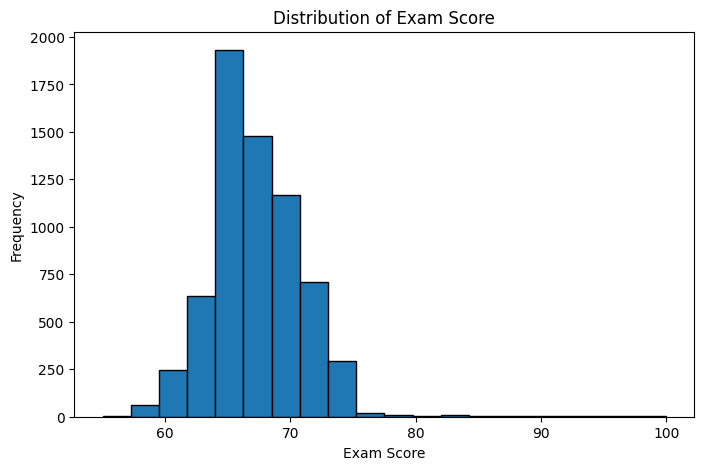

In [24]:
# exam score distribution

plt.figure(figsize=(8, 5))

plt.hist(
    clean_df["Exam_Score"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Exam Score")
plt.xlabel("Exam Score")
plt.ylabel("Frequency")

plt.show()

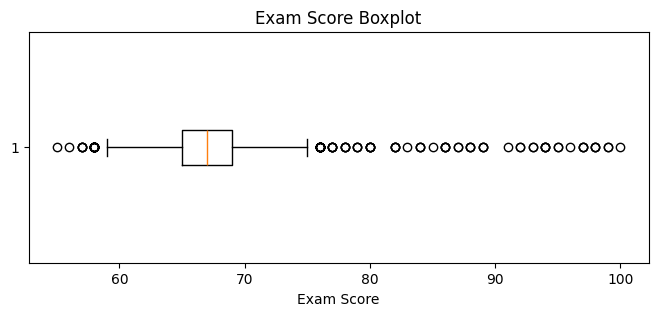

In [25]:
# exam score boxplot

plt.figure(figsize=(8, 3))

plt.boxplot(
    clean_df["Exam_Score"],
    vert=False
)

plt.title("Exam Score Boxplot")
plt.xlabel("Exam Score")

plt.show()

## Interpretación de Exam_Score

La distribución de Exam_Score se concentra principalmente alrededor de los puntajes medios y presenta una dispersión relativamente pequeña para la mayoría de los estudiantes.

El diagrama de caja permite observar algunos valores alejados del grupo principal. Sin embargo, después de eliminar los puntajes imposibles superiores a 100, estos valores siguen siendo resultados válidos dentro de la escala del examen.

Por esta razón, no se eliminaron únicamente por ser considerados outliers estadísticos.

La variable es numérica y continua para efectos del modelado, por lo que resulta apropiada como variable objetivo para un futuro problema de regresión.

In [26]:
# numerical variables statistics

selected_numeric = [
    "Hours_Studied",
    "Attendance"
]

display(clean_df[selected_numeric].describe())

,Hours_Studied,Attendance
count,6606.000000,6606.000000
mean,19.974266,79.974720
std,5.990424,11.546219
min,1.000000,60.000000
25%,16.000000,70.000000
50%,20.000000,80.000000
75%,24.000000,90.000000
max,44.000000,100.000000


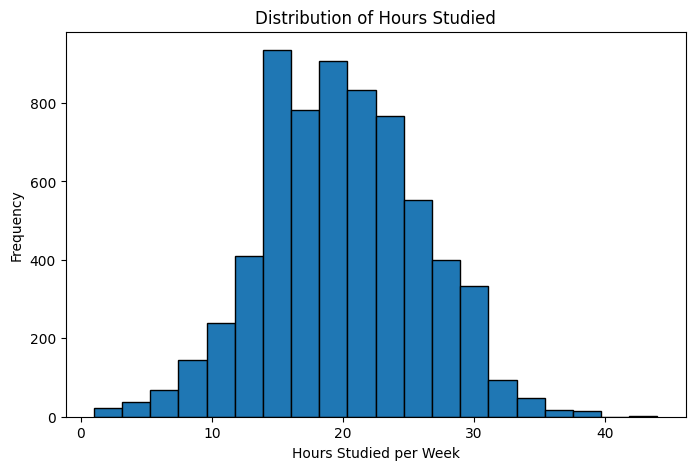

In [27]:
# hours studied distribution

plt.figure(figsize=(8, 5))

plt.hist(
    clean_df["Hours_Studied"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Hours Studied")
plt.xlabel("Hours Studied per Week")
plt.ylabel("Frequency")

plt.show()

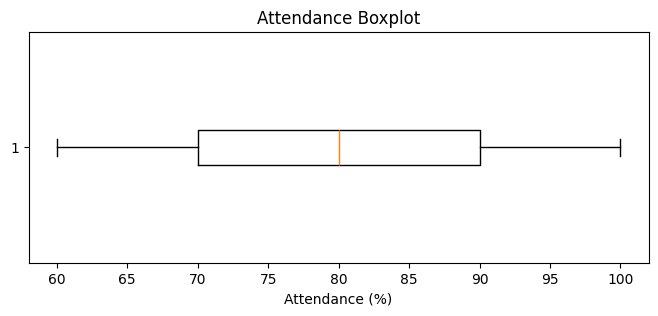

In [28]:
# attendance boxplot

plt.figure(figsize=(8, 3))

plt.boxplot(
    clean_df["Attendance"],
    vert=False
)

plt.title("Attendance Boxplot")
plt.xlabel("Attendance (%)")

plt.show()

## Interpretación de variables numéricas

### Hours_Studied

Hours_Studied muestra diferencias importantes en el número de horas que los estudiantes dedican al estudio semanal.

Existen algunos valores alejados del centro de la distribución, pero continúan siendo cantidades posibles de horas de estudio. Por esta razón, no se eliminaron automáticamente.

### Attendance

Attendance representa el porcentaje de asistencia a clases.

Sus valores se mantienen dentro del rango válido de 0 a 100. La distribución permite observar si la mayoría de los estudiantes presenta niveles altos, medios o bajos de asistencia.

Ambas variables podrían ser relevantes posteriormente para explicar o predecir Exam_Score.

In [29]:
# categorical frequencies

print("Parental Involvement:")
display(clean_df["Parental_Involvement"].value_counts())

print("\nSchool Type:")
display(clean_df["School_Type"].value_counts())

Parental Involvement:


,count
Parental_Involvement,
Medium,3362
High,1908
Low,1336



School Type:


,count
School_Type,
Public,4597
Private,2009


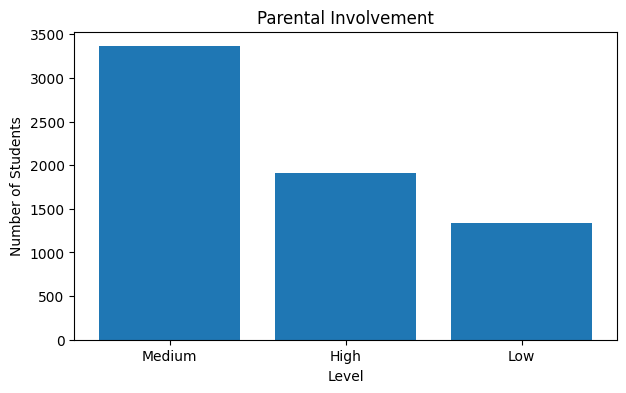

In [30]:
# parental involvement distribution

counts = clean_df["Parental_Involvement"].value_counts()

plt.figure(figsize=(7, 4))

plt.bar(counts.index, counts.values)

plt.title("Parental Involvement")
plt.xlabel("Level")
plt.ylabel("Number of Students")

plt.show()

## Interpretación de variables categóricas

### Parental_Involvement

Parental_Involvement presenta categorías con un orden conceptual: Low, Medium y High.

Debido a que existe una progresión entre los niveles, esta variable puede representarse posteriormente mediante codificación ordinal.

### School_Type

School_Type distingue entre tipos de escuela.

Las categorías no representan una jerarquía: una escuela privada no es numéricamente "mayor" que una pública. Por esta razón, esta variable debe tratarse como nominal.

Las tablas de frecuencia también permiten verificar categorías poco comunes o inconsistencias de escritura. Después de la limpieza, cada concepto tiene una representación consistente.

In [31]:
# encoding demonstration

encoding_demo = clean_df[
    [
        "School_Type",
        "Gender",
        "Parental_Involvement",
        "Motivation_Level"
    ]
].head(10).copy()

print("before encoding:")
display(encoding_demo)

before encoding:


,School_Type,Gender,Parental_Involvement,Motivation_Level
0,Public,Male,Low,Low
1,Public,Female,Low,Low
2,Public,Male,Medium,Medium
3,Public,Male,Low,Medium
4,Public,Female,Medium,Medium
5,Public,Male,Medium,Medium
6,Private,Male,Medium,Low
7,Public,Male,Low,Medium
8,Private,Male,Medium,High
9,Public,Male,Medium,Medium


In [32]:
# ordinal encoding

ordinal_map = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

encoding_demo["Parental_Involvement"] = (
    encoding_demo["Parental_Involvement"].map(ordinal_map)
)

encoding_demo["Motivation_Level"] = (
    encoding_demo["Motivation_Level"].map(ordinal_map)
)

# one-hot encoding

encoding_demo = pd.get_dummies(
    encoding_demo,
    columns=["School_Type", "Gender"],
    dtype=int
)

print("after encoding:")
display(encoding_demo)

after encoding:


,Parental_Involvement,Motivation_Level,School_Type_Private,School_Type_Public,Gender_Female,Gender_Male
0,0,0,0,1,0,1
1,0,0,0,1,1,0
2,1,1,0,1,0,1
3,0,1,0,1,0,1
4,1,1,0,1,1,0
5,1,1,0,1,0,1
6,1,0,1,0,0,1
7,0,1,0,1,0,1
8,1,2,1,0,0,1
9,1,1,0,1,0,1


## Codificación de variables categóricas

Se utilizaron dos estrategias diferentes.

**School_Type y Gender** son variables nominales. Sus categorías representan grupos diferentes, pero no existe un orden entre ellos. Por esta razón se utiliza One-Hot Encoding, creando una columna binaria para cada categoría.

**Parental_Involvement y Motivation_Level** sí tienen un orden lógico:

Low → Medium → High

Por esta razón se utiliza codificación ordinal:

Low = 0  
Medium = 1  
High = 2

La diferencia principal es que la codificación ordinal conserva información sobre el orden de las categorías, mientras que One-Hot Encoding evita crear una jerarquía artificial entre categorías nominales.

In [33]:
# scaling demonstration

scale_columns = [
    "Hours_Studied",
    "Attendance",
    "Previous_Scores"
]

before_scaling = clean_df[scale_columns].head().copy()

scaler = StandardScaler()

scaled_values = scaler.fit_transform(
    clean_df[scale_columns]
)

scaled_demo = pd.DataFrame(
    scaled_values,
    columns=scale_columns
)

after_scaling = scaled_demo.head()

print("before scaling:")
display(before_scaling)

print("after scaling:")
display(after_scaling)

before scaling:


,Hours_Studied,Attendance,Previous_Scores
0,23,84,73
1,19,64,59
2,24,98,91
3,29,89,98
4,19,92,65


after scaling:


,Hours_Studied,Attendance,Previous_Scores
0,0.505133,0.348650,-0.143617
1,-0.162650,-1.383650,-1.115968
2,0.672079,1.561259,1.106548
3,1.506808,0.781725,1.592723
4,-0.162650,1.041570,-0.699247


In [34]:
# compare statistics

comparison = pd.DataFrame({
    "Original_Mean": clean_df[scale_columns].mean(),
    "Original_Std": clean_df[scale_columns].std(),
    "Scaled_Mean": scaled_demo.mean(),
    "Scaled_Std": scaled_demo.std()
})

display(comparison)

,Original_Mean,Original_Std,Scaled_Mean,Scaled_Std
Hours_Studied,19.974266,5.990424,-1.936084e-17,1.000076
Attendance,79.974720,11.546219,-5.001550e-16,1.000076
Previous_Scores,75.067817,14.399184,-4.883233e-16,1.000076


## Interpretación del escalamiento

StandardScaler transforma las variables para que tengan aproximadamente una media de 0 y una desviación estándar de 1.

El escalamiento no elimina registros ni modifica la relación relativa entre los estudiantes. La información sobre qué observaciones tienen valores mayores o menores se conserva.

Lo que cambia es la escala utilizada para representar los datos.

Esto es importante porque algunos algoritmos calculan distancias o asignan importancia a la magnitud de las variables. Sin escalamiento, una variable con números grandes puede tener una influencia artificialmente mayor que otra variable medida con números pequeños.

In [35]:
# define features

numeric_features = [
    "Hours_Studied",
    "Attendance",
    "Sleep_Hours",
    "Previous_Scores",
    "Tutoring_Sessions",
    "Physical_Activity"
]

ordinal_features = [
    "Parental_Involvement",
    "Access_to_Resources",
    "Motivation_Level",
    "Family_Income",
    "Teacher_Quality",
    "Peer_Influence",
    "Parental_Education_Level",
    "Distance_from_Home"
]

nominal_features = [
    "Extracurricular_Activities",
    "Internet_Access",
    "School_Type",
    "Learning_Disabilities",
    "Gender"
]



# transformation plan

transformation_plan = pd.DataFrame({
    "Variables": [
        ", ".join(numeric_features),
        ", ".join(ordinal_features),
        ", ".join(nominal_features)
    ],

    "Transformation": [
        "StandardScaler",
        "OrdinalEncoder",
        "OneHotEncoder"
    ],

    "Reason": [
        "Place numerical variables on a comparable scale",
        "Preserve the natural order of categories",
        "Represent categories without creating a false order"
    ]
})

display(transformation_plan)

,Variables,Transformation,Reason
0,"Hours_Studied, Attendance, Sleep_Hours, Previo...",StandardScaler,Place numerical variables on a comparable scale
1,"Parental_Involvement, Access_to_Resources, Mot...",OrdinalEncoder,Preserve the natural order of categories
2,"Extracurricular_Activities, Internet_Access, S...",OneHotEncoder,Represent categories without creating a false ...


In [36]:
# ordinal category order

ordinal_categories = [
    ["Low", "Medium", "High"],
    ["Low", "Medium", "High"],
    ["Low", "Medium", "High"],
    ["Low", "Medium", "High"],
    ["Low", "Medium", "High"],
    ["Negative", "Neutral", "Positive"],
    ["High School", "College", "Postgraduate"],
    ["Near", "Moderate", "Far"]
]

# numerical pipeline

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

# ordinal pipeline

ordinal_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OrdinalEncoder(
            categories=ordinal_categories,
            handle_unknown="use_encoded_value",
            unknown_value=-1
        )
    )
])

# nominal pipeline

nominal_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

In [37]:
# combine transformations

preprocessor = ColumnTransformer([
    (
        "num",
        numeric_pipeline,
        numeric_features
    ),
    (
        "ord",
        ordinal_pipeline,
        ordinal_features
    ),
    (
        "nom",
        nominal_pipeline,
        nominal_features
    )
])

X = clean_df.drop(columns="Exam_Score")
y = clean_df["Exam_Score"]

X_prepared = preprocessor.fit_transform(X)

feature_names = preprocessor.get_feature_names_out()

feature_names = [
    name.split("__", 1)[1]
    if "__" in name
    else name
    for name in feature_names
]

prepared_df = pd.DataFrame(
    X_prepared,
    columns=feature_names
)

prepared_df["Exam_Score"] = y.reset_index(drop=True)

prepared_df.head()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Parental_Involvement,Access_to_Resources,Motivation_Level,Family_Income,...,Extracurricular_Activities_Yes,Internet_Access_No,Internet_Access_Yes,School_Type_Private,School_Type_Public,Learning_Disabilities_No,Learning_Disabilities_Yes,Gender_Female,Gender_Male,Exam_Score
0,0.505133,0.348650,-0.019901,-0.143617,-1.214158,0.031414,0.0,2.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,67
1,-0.162650,-1.383650,0.661268,-1.115968,0.412105,1.001129,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,61
2,0.672079,1.561259,-0.019901,1.106548,0.412105,1.001129,1.0,1.0,1.0,1.0,...,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,74
3,1.506808,0.781725,0.661268,1.592723,-0.401027,1.001129,0.0,1.0,1.0,1.0,...,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,71
4,-0.162650,1.041570,-0.701069,-0.699247,1.225236,1.001129,1.0,1.0,1.0,1.0,...,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,70


## Reproducibilidad y prevención de fuga de información

ColumnTransformer y Pipeline permiten organizar de manera reproducible las transformaciones aplicadas a diferentes tipos de variables.

En este notebook las transformaciones se ajustan utilizando todo el dataset únicamente para demostrar y exportar la preparación solicitada.

Sin embargo, durante la etapa de modelado no debe realizarse de esta forma.

Primero se deberán separar los datos en entrenamiento y prueba. Después, el Pipeline deberá ajustarse exclusivamente utilizando los datos de entrenamiento.

Los datos de prueba solamente deberán transformarse utilizando los parámetros aprendidos durante el entrenamiento.

Esto evita que información del conjunto de prueba influya indirectamente en el entrenamiento del modelo.

In [38]:
# initial vs final comparison

comparison_table = pd.DataFrame({
    "Elemento": [
        "Número de registros",
        "Número de variables",
        "Valores faltantes",
        "Registros duplicados",
        "Variables categóricas transformadas",
        "Variables numéricas escaladas"
    ],

    "Estado inicial": [
        initial_rows,
        initial_cols,
        initial_missing,
        initial_duplicates,
        0,
        0
    ],

    "Estado final": [
        prepared_df.shape[0],
        prepared_df.shape[1],
        int(prepared_df.isna().sum().sum()),
        int(prepared_df.duplicated().sum()),
        len(ordinal_features) + len(nominal_features),
        len(numeric_features)
    ]
})

display(comparison_table)

,Elemento,Estado inicial,Estado final
0,Número de registros,6607,6606
1,Número de variables,20,25
2,Valores faltantes,235,0
3,Registros duplicados,0,0
4,Variables categóricas transformadas,0,13
5,Variables numéricas escaladas,0,6


In [39]:
# final verification

print("final shape:")
print(prepared_df.shape)

print("\nmissing values:")
print(prepared_df.isna().sum().sum())

print("\nduplicates:")
print(prepared_df.duplicated().sum())

print("\ndata types:")
print(prepared_df.dtypes.value_counts())

print("\ntarget available:")
print("Exam_Score" in prepared_df.columns)

final shape:
(6606, 25)

missing values:
0

duplicates:
0

data types:
float64    24
int64       1
Name: count, dtype: int64

target available:
True


In [40]:
# export prepared dataset

file_name = "StudentPerformanceFactors_prepared.csv"

prepared_df.to_csv(
    file_name,
    index=False
)

print("file created:", file_name)

file created: StudentPerformanceFactors_prepared.csv


In [41]:
# reload exported dataset

test_df = pd.read_csv(
    "StudentPerformanceFactors_prepared.csv"
)

print("loaded successfully")
print(test_df.shape)

display(test_df.head())

loaded successfully
(6606, 25)


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Parental_Involvement,Access_to_Resources,Motivation_Level,Family_Income,...,Extracurricular_Activities_Yes,Internet_Access_No,Internet_Access_Yes,School_Type_Private,School_Type_Public,Learning_Disabilities_No,Learning_Disabilities_Yes,Gender_Female,Gender_Male,Exam_Score
0,0.505133,0.348650,-0.019901,-0.143617,-1.214158,0.031414,0.0,2.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,67
1,-0.162650,-1.383650,0.661268,-1.115968,0.412105,1.001129,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,61
2,0.672079,1.561259,-0.019901,1.106548,0.412105,1.001129,1.0,1.0,1.0,1.0,...,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,74
3,1.506808,0.781725,0.661268,1.592723,-0.401027,1.001129,0.0,1.0,1.0,1.0,...,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,71
4,-0.162650,1.041570,-0.701069,-0.699247,1.225236,1.001129,1.0,1.0,1.0,1.0,...,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,70


In [42]:
# download prepared dataset

files.download(
    "StudentPerformanceFactors_prepared.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Conclusión

La exploración inicial permitió identificar que Student Performance Factors contiene variables numéricas y categóricas relacionadas con factores académicos, personales, familiares y escolares.

Los principales problemas encontrados fueron valores faltantes en algunas variables categóricas y un valor de Exam_Score fuera del rango esperado. También se analizaron posibles outliers, pero estos no fueron eliminados automáticamente cuando representaban valores plausibles.

Durante la limpieza se estandarizaron nombres y categorías, se corrigieron tipos de datos, se trataron valores faltantes, se eliminaron duplicados cuando correspondía y se filtraron valores imposibles.

Las variables categóricas nominales fueron transformadas mediante One-Hot Encoding, mientras que las variables con un orden natural fueron tratadas mediante codificación ordinal. Las variables numéricas se estandarizaron utilizando StandardScaler.

El escalamiento modifica la magnitud de las variables pero conserva sus relaciones relativas, mientras que la codificación permite representar información categórica en un formato que los algoritmos de aprendizaje automático pueden procesar.

Una limitación importante es que el dataset es sintético, por lo que los patrones encontrados no necesariamente representan exactamente el comportamiento de una población estudiantil real.

El siguiente paso sería dividir los datos en conjuntos de entrenamiento y prueba. Posteriormente, las transformaciones deberían ajustarse únicamente utilizando los datos de entrenamiento para evitar fuga de información y finalmente podría entrenarse y evaluarse un modelo de regresión para predecir Exam_Score.